#Librerias utilizadas

##requests
* Sirve para hacer solicitudes HTTP (GET, POST, etc.) desde Python.
* Permite descargar archivos, consultar APIs y acceder a páginas web directamente desde tu código.

##os
* Es la librería estándar de Python para interactuar con el sistema operativo.
* Permite trabajar con archivos y directorios, obtener información del entorno y manipular rutas.

In [2]:
import requests
import os

# URL directa al PDF
url = "https://repositorio.cepal.org/bitstreams/6c295402-7c60-4673-bbe7-2166ec01de47/download"

# Descargar el archivo
response = requests.get(url)

# Guardar en tu entorno de Colab
with open("cepal_ia.pdf", "wb") as f:
    f.write(response.content)

In [3]:
# Verificar existencia y tamaño
if os.path.exists("cepal_ia.pdf"):
    size = os.path.getsize("cepal_ia.pdf") / (1024*1024)  # tamaño en MB
    print(f"El archivo 'cepal_ia.pdf' existe y pesa {size:.2f} MB.")
else:
    print("Error: el archivo no se encuentra en el directorio actual.")

El archivo 'cepal_ia.pdf' existe y pesa 37.85 MB.


#Libreria utilizada PyMuPDF

* Abrir y leer PDFs: cargar documentos y recorrer sus páginas.

* Extraer texto: obtener el contenido de cada página en distintos modos (texto plano, bloques, HTML).

* Extraer imágenes: recuperar imágenes incrustadas en el PDF.

* Metadatos: acceder a información como título, autor, fecha de creación.

* Manipulación avanzada: rotar páginas, recortar, insertar o eliminar páginas, añadir anotaciones.

* Soporte para múltiples formatos: además de PDF, puede abrir XPS, EPUB y varios tipos de imágenes.

In [4]:
# Instalamos PyMuPDF
!pip install PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 64.9 MB/s eta 0:00:00


In [14]:
import fitz  # PyMuPDF

# Abrir el PDF descargado
doc = fitz.open("cepal_ia.pdf")

# Extraer metadatos
metadata = doc.metadata

print("Metadatos del PDF:")
for nombre, valor in metadata.items():
    print(f"{nombre}: {valor}")

# Número de páginas
print(f"El documento tiene {doc.page_count} páginas.")


Metadatos del PDF:
format: PDF 1.7
title: Índice Latinoamericano de Inteligencia Artificial (ILIA) 2025. Hallazgos principales, IA aplicada y talento humano
author: CEPAL
subject: Con gran satisfacción presentamos la tercera edición del Índice Latinoamericano de Inteligencia Artificial (ILIA). Esta versión robustece al instrumento mediante mecanismos de seguimiento de fenómenos más dinámicos y capilares de la IA en América Latina y el Caribe. La primera edición del ILIA, publicada en 2023, estableció una línea de base sobre el nivel de preparación de la región ante la creciente revolución de la IA, mediante la cuantificación de factores habilitantes. La segunda edición, publicada en 2024, amplió la cobertura de países e indicadores y comenzó el tránsito desde la medición de habilitadores hacia la medición de  avances en el uso de la IA. En esta tercera edición, el ILIA profundiza en la adopción y el capital humano, tanto habilitante como avanzado, por considerarlos señales fieles del p

In [15]:
# Abrir el PDF
doc = fitz.open("cepal_ia.pdf")

# Extraer texto crudo de las primeras 5 páginas
for page_num in range(5):
    page = doc[page_num]
    text = page.get_text("text")  # función clave: get_text()
    print(f"\n--- Página {page_num+1} ---\n")
    print(text)



--- Página 1 ---

TERCERA EDICIÓN
Índice
Latinoamericano
DE INTELIGENCIA
ARTIFICIAL
2025
HALLAZGOS PRINCIPALES, IA 
APLICADA Y TALENTO HUMANO


--- Página 2 ---

Este documento fue coordinado por Álvaro Soto, Rodrigo Durán, Antonia Moreno y Sebastián 
Adasme, del Centro Nacional de Inteligencia Artificial (CENIA) de Chile, y Sebastián Rovira, Valeria 
Jordán y Laura Poveda, funcionarios de la División de Desarrollo Productivo y Empresarial de la 
Comisión Económica para América Latina y el Caribe (CEPAL).
En su elaboración participaron Rodrigo Oportot y Verona Lesseigneur, del CENIA, quienes contaron 
con el apoyo de Demetris Herakleous, Francisca Lira, funcionarios, y Tomás Rodrigues, Consultor, 
de la CEPAL, y Salma Jalife, Alberto Farca y Susana Cruz, del Centro México Digital.
El documento se elaboró en el marco de la Alianza Digital Unión Europea-América Latina y el Caribe 
y contó con el financiamiento de la Unión Europea, a través de la estrategia Global Gateway.
Ni la Unión Eu

#Analisis de resultado

##Pagina 1

La portada. El texto está fragmentado en líneas cortas porque el PDF guarda cada bloque como un salto de línea (\n).

“Índice / Latinoamericano / DE INTELIGENCIA / ARTIFICIAL” en líneas separadas.

##Pagina 2

Es la sección de créditos y derechos. Se nota que los párrafos están separados por saltos de línea simples

##Pagina 3 y 4

Muestran el índice. Los títulos (“CONTENIDOS”, “DIMENSIÓN”, “CASO DE ÉXITO…”) aparecen en mayúsculas y separados por saltos de línea. Los números de página también se intercalan en medio del texto.

##Pagina 5

El prólogo “Tiempo de Actuar”. Acá son párrafos más largos, pero igualmente cortados por saltos de línea (\n) en lugares donde el PDF tenía un salto visual.

#Conclusiones
La librería PyMuPDF con get_text("text") devuelve el contenido crudo.

Los párrafos y secciones se separan principalmente con saltos de línea (\n).

Los títulos aparecen en mayúsculas y con saltos adicionales.


## Informe del proceso de extracción de la tabla (CEPAL – página 124)

###1. Primer intento con pdfplumber

* Se utilizó pdfplumber para abrir el PDF y aplicar extract_tables() en la página 124.

* Resultado: detectó una tabla, pero las celdas aparecían vacías o con valores None.

* Problema: la tabla no estaba codificada como texto tabular, sino como bloques gráficos.

###2. Segundo intento con tabula-py

* Se probó tabula.read_pdf() indicando el área de la página.

* Resultado: devolvió párrafos de texto corrido, no las filas de la tabla.

* Problema: la tabla estaba incrustada como imagen, por lo que Tabula tampoco pudo reconocerla.

###3. Extracción de texto con pdfplumber

* Se usó extract_text() para obtener todo el contenido de la página.

* Resultado: recuperamos los párrafos, pero la tabla se “salteaba” porque no era texto real.

* Confirmación: la tabla estaba embebida como imagen dentro del PDF.

###4. Solución definitiva con pdf2image + pytesseract

* Se convirtió la página 124 a imagen con pdf2image.

* Se aplicó OCR con pytesseract en español para reconocer el texto dentro de la imagen.

* Se filtraron las líneas que contenían porcentajes (%) o la frase “Sin diferencia”.

* Se reconstruyeron manualmente las columnas: Herramienta de IA, Control, Tratamiento y Diferencia

###5. Limpieza y exportación

* Se ajustó el parser para que la columna Diferencia quedara completa (+33.3 pts, Sin diferencia, etc.).

* Se convirtieron las columnas Control y Tratamiento a valores numéricos.

* Se obtuvo un DataFrame fiel al cuadro original:


###Conclusión

* pdfplumber y tabula-py no funcionaron porque la tabla estaba como imagen.

* La solución definitiva fue usar OCR con pdf2image + pytesseract, que permitió recuperar los datos y estructurarlos en un DataFrame.

* Ahora los datos están listos para análisis, visualización y exportación.

In [16]:
!pip install pdf2image
!pip install pytesseract
!apt-get install -y tesseract-ocr
!apt-get install -y tesseract-ocr-spa  # paquete de idioma español
!apt-get install -y poppler-utils


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr-spa is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


* pdf2image convierte páginas de PDF en imágenes.

* pytesseract extrae texto de esas imágenes.

* tesseract-ocr es el motor OCR.

* tesseract-ocr-spa agrega soporte para español.

* poppler-utils provee las herramientas (pdfinfo, pdftoppm) que pdf2image necesita para funcionar.

In [17]:
from pdf2image import convert_from_path
import pytesseract
import pandas as pd

# 1. Convertir página 124 a imagen
pages = convert_from_path("cepal_ia.pdf", first_page=124, last_page=124)
img = pages[0]

# 2. OCR con pytesseract en español
text = pytesseract.image_to_string(img, lang="spa")

# 3. Parsear las filas de la tabla
lines = text.split("\n")
rows = [line for line in lines if "%" in line or "Sin diferencia" in line]

data = []
for row in rows:
    parts = row.split()
    if len(parts) >= 5:
        herramienta = " ".join(parts[:-4])  # todo menos las últimas 4 palabras
        control = parts[-4].replace("%","")
        tratamiento = parts[-3].replace("%","")
        diferencia = " ".join(parts[-2:])   # últimas dos palabras juntas
        try:
            control_val = float(control)
            tratamiento_val = float(tratamiento)
            data.append([herramienta, control_val, tratamiento_val, diferencia])
        except ValueError:
            continue

# 4. Crear DataFrame limpio
df = pd.DataFrame(data, columns=["Herramienta de IA", "Control", "Tratamiento", "Diferencia"])
print(df)

# 5. Exportar a CSV y Excel
df.to_csv("tabla_ilia124.csv", index=False)
df.to_excel("tabla_ilia124.xlsx", index=False)

print("Archivos exportados: tabla_ilia124.csv y tabla_ilia124.xlsx")


                                  Herramienta de IA  Control  Tratamiento  \
0             Automatización de procesos de negocio     50.0         83.3   
1  Análisis predictivo para ventas, demanda, etc. |     50.0         66.7   
2                         Sistemas de recomendación     12.5         50.0   
3                 Procesamiento de lenguaje natural     50.0         50.0   
4                             Visión por computador     25.0         33.3   

       Diferencia  
0       +33.3 pts  
1       +16.7 pts  
2       +37.5 pts  
3  Sin diferencia  
4        +8.3 pts  
Archivos exportados: tabla_ilia124.csv y tabla_ilia124.xlsx


#Procedimiento

##Paso 1 - Convertir PDF a imagen
* Usa pdf2image para transformar la página 124 del PDF en una imagen.

* Esto es necesario porque esa página está escaneada y no tiene texto digitalizado.

##Paso 2 - Aplicar OCR con Tesseract
* Usa pytesseract para reconocer caracteres en la imagen.

* El parámetro lang="spa" indica que el texto está en español, mejorando la precisión.

##Paso 3 - Parsear filas de la tabla
* Divide el texto en líneas.

* Filtra solo aquellas que parecen ser filas de la tabla (contienen porcentajes o la frase “Sin diferencia”).

##Paso 4 - Procesar cada fila
* Divide cada fila en palabras.

* Reconstruye la columna “Herramienta de IA” con todo menos los últimos 4 tokens.

* Extrae los valores de Control y Tratamiento (quitando el símbolo %).

* Une las últimas dos palabras como la columna “Diferencia”.

##Paso 5 - Crear DataFrame limpio
* Organiza los datos en una tabla estructurada con pandas.

* Esto facilita análisis y visualización posteriores.

##Paso 6 - Exportar resultados
* Guarda la tabla en dos formatos: CSV y Excel.

* Así podés abrirla en cualquier herramienta de análisis o compartirla fácilmente.

#Librerias utilizadas

* NLTK: librería principal para procesamiento de texto.

* stopwords: lista de palabras irrelevantes que se eliminan.

* word_tokenize: divide el texto en palabras.

* string: ayuda a quitar puntuación.

* punkt: modelo base de tokenización.

* stopwords (descarga): lista de palabras comunes en español.

* punkt_tab: soporte específico para tokenización en español.

In [19]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Descargar recursos de NLTK (solo la primera vez)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')  # Para tokenizar en español

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [20]:
# Tomamos como ejemplo el texto de la página 5
page = doc[4]
text = page.get_text("text")

# Normalización: minúsculas y sin puntuación
text = text.lower()
text = text.translate(str.maketrans("", "", string.punctuation))

# Tokenización en español
tokens = word_tokenize(text, language="spanish")

# Eliminación de stopwords
stop_words = set(stopwords.words("spanish"))
tokens_clean = [word for word in tokens if word not in stop_words]
'''Desglose
tokens_clean = [...]
Crea una nueva lista llamada tokens_clean. Esa lista va a contener solo las palabras que pasen el filtro.

for word in tokens
Recorre cada elemento de la lista tokens. Recordá que tokens es el resultado de la tokenización: una lista de palabras individuales extraídas del texto.

if word not in stop_words
Condición que se aplica a cada palabra.

stop_words es el conjunto de palabras irrelevantes en español (ej. “de”, “la”, “y”).

Si la palabra no está en esa lista, se incluye en la nueva lista.

Si la palabra sí está en stop_words, se descarta.'''

print("Tokens limpios:", tokens_clean[:50])  # mostramos los primeros 50



Tokens limpios: ['ilia', '2025', '5', 'tiempo', 'actuar', 'tiempo', 'actuar', 'gran', 'satisfacción', 'presentamos', 'tercera', 'edición', 'índice', 'latinoamericano', 'inteligencia', 'artificial', 'ilia', 'versión', 'robustece', 'instrumento', 'mediante', 'mecanismos', 'seguimiento', 'fenómenos', 'dinámicos', 'capilares', 'ia', 'américa', 'latina', 'caribe', 'primera', 'edición', 'ilia', 'publicada', '2023', 'estableció', 'línea', 'base', 'nivel', 'preparación', 'región', 'creciente', 'revolución', 'ia', 'mediante', 'cuantificación', 'factores', 'habilitantes', 'segunda', 'edición']


# Librerias utilizadas
## Counter
* Counter es una clase de la librería estándar de Python, dentro del módulo collections.

* Se usa para contar la frecuencia de elementos en una lista, tuplas o cualquier iterable.

* Devuelve un diccionario especial donde las claves son los elementos y los valores son las veces que aparecen.

## matplotlib.pyplot
* matplotlib.pyplot es un módulo de la librería matplotlib, la más usada en Python para gráficos.

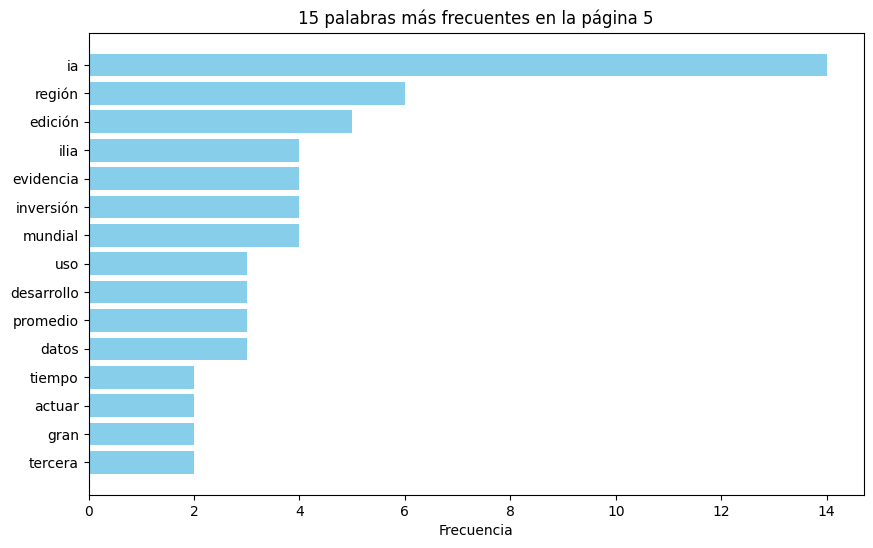

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# Conteo de frecuencias
freq = Counter(tokens_clean)

# Seleccionar las 15 más frecuentes
common_words = freq.most_common(15)

# Visualización
words, counts = zip(*common_words)
plt.figure(figsize=(10,6))
plt.barh(words, counts, color="skyblue")
plt.xlabel("Frecuencia")
plt.title("15 palabras más frecuentes en la página 5")
plt.gca().invert_yaxis()  # para que la palabra más frecuente quede arriba
plt.show()
